# Import functions

In [7]:
from google.colab import drive
drive.mount('/content/drive')

! pip install jaxopt
! pip install corner
! pip install emcee
! pip install blackjax jax==0.7.2 jaxlib==0.7.2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "true"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"
print(os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"])

path = '/content/drive/MyDrive/SchwarMAX/'

import sys
sys.path.append(path)

import jax
import jax.numpy as jnp

from tqdm import tqdm
import numpy as np
import scipy as sp
from scipy.interpolate import griddata
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from functools import partial

# SchwarMAX package
from utils import logMenc_logc_to_logM_logRs, load_data_bootstrap
from constants import EPSILON, KPCGYR_TO_KMS
from model import build_model, model_deltaChi2_jackknife
from potentials import NFW_potential, MiyamotoNagai_potential, MiyamotoNagai_density, T3_density, T3_potential, V4_density, V4_potential

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
0.95


# Use the Schwarzschild function in SchwarMAX to build model likelihood

In [3]:
# ---- Fixed V4 bulge parameters ----
V4_A, V4_B, V4_L, V4_GAMMA = 0.5, 0.5, 0.1, 0.0
GAMMA_BAR = 1.0

# Specify the density and potential functions that you will use in the Schwarzschild model
# For both, it should take positions and density/potential parameters in and output the density/potential at the locations
@jax.jit
def density_func(x, y, z, params):

    # MN disc density
    mn_params = {
        'logM_disc': params['logM_disc'],
        'Rs_disc': params['Rs_disc'],
        'Hs_disc': params['Hs_disc'],
        'x_origin': params['x_origin'],
        'y_origin': params['y_origin'],
        'z_origin': params['z_origin'],
        'dirx': params['dirx'],
        'diry': params['diry'],
        'dirz': params['dirz'],
    }
    rho_mn = MiyamotoNagai_density(x, y, z, mn_params)

    # T3 bar density
    M_bar = 10.0 ** params['logM_bar']
    L_bar = params['L_bar']
    a_bar = params['a_bar']
    b_bar = params['b_bar']
    rho_t3 = T3_density(x, y, z, M_bar, a_bar, b_bar, L_bar, GAMMA_BAR)

    # V4 bulge density (M = M_bar, fixed shape)
    rho_v4 = V4_density(x, y, z, M_bar, V4_A, V4_B, V4_L, V4_GAMMA)

    return rho_mn + rho_t3 + rho_v4

@jax.jit
def potential_func(x, y, z, params_baryon, params_halo):

    phi_halo = NFW_potential(x, y, z, params_halo)

    mn_params = {
        'logM_disc': params_baryon['logM_disc'],
        'Rs_disc': params_baryon['Rs_disc'],
        'Hs_disc': params_baryon['Hs_disc'],
        'x_origin': params_baryon['x_origin'],
        'y_origin': params_baryon['y_origin'],
        'z_origin': params_baryon['z_origin'],
        'dirx': params_baryon['dirx'],
        'diry': params_baryon['diry'],
        'dirz': params_baryon['dirz'],
    }
    phi_mn = MiyamotoNagai_potential(x, y, z, mn_params)

    M_bar = 10.0 ** params_baryon['logM_bar']
    L_bar = params_baryon['L_bar']
    a_bar = params_baryon['a_bar']
    b_bar = params_baryon['b_bar']
    phi_t3 = T3_potential(x, y, z, M_bar, a_bar, b_bar, L_bar, GAMMA_BAR)
    phi_v4 = V4_potential(x, y, z, M_bar, V4_A, V4_B, V4_L, V4_GAMMA)

    return phi_halo + phi_mn + phi_t3 + phi_v4

# An example function that use SchwarMAX to build Schwarzschild model
@partial(jax.jit, static_argnames=('num_Vbin', 'Rzphi_n_tot'))
def model_likelihood(params, dict_data, num_Vbin, Rzphi_n_tot, sigma_amplify=1.0):
    """
    params: jnp array, free parameters in the density and potential models
    dict_data: dict, a dictionary that contains the data, binning stregety, initial spatial configuration of the test particles (see load_data_bootstrap below)
    num_Vbin: int, the total number of Voronoi binning (required to specify because the way JAX works)
    Rzphi_n_tot: int, the total number of Rzphi bins (required to specify because the way JAX works)
    sigma_amplify: float, sqrt(delta_chi2) as the denomenator of the final log-likelihood
    """

    # First specify the free parameters of the density/potential
    logM_enc = params[0]
    log_c = params[3]
    logM_halo, logRs_halo = logMenc_logc_to_logM_logRs(logM_enc, log_c, r_enc=10.0, Delta=200., rho_crit=277.54)

    logM_disc = params[1]
    logM_bar = params[2]
    logRs_disk = params[4]
    logHs_disk = params[5]
    logL_bar = params[6]
    alpha = params[7]
    beta = params[8]
    gamma = params[9]
    log_mass_to_light_ratio = params[10]
    log_Omega_bar = params[11]

    alpha = alpha * 180 / jnp.pi
    beta = beta * 180 / jnp.pi
    gamma = gamma * 180 / jnp.pi

    # Derived bar parameters
    L_bar = 10.0 ** logL_bar
    a_bar = L_bar / 5.0
    Hs_disc = 10.0 ** logHs_disk
    b_bar = Hs_disc

    params_halo_pot = {
        'logM': logM_halo,
        'Rs':10 ** logRs_halo,
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_baryon_rho = {
        'logM_disc': logM_disc,
        'Rs_disc': 10 ** logRs_disk,
        'Hs_disc': Hs_disc,
        'logM_bar': logM_bar,
        'L_bar': L_bar,
        'a_bar': a_bar,
        'b_bar': b_bar,
        'mass_to_light_ratio': 10 ** log_mass_to_light_ratio,
        'Omega_bar': 10 ** log_Omega_bar,
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0,
        'alpha': alpha,
        'beta': beta,
        'gamma': gamma,
    }

    X_minmax = dict_data['X_minmax']
    Y_minmax = dict_data['Y_minmax']
    nX, nY = dict_data['nX_nY']
    xy_lim_grid = jnp.array([X_minmax, Y_minmax])
    xy_n_grid = jnp.array([nX, nY])

    Rmin, Rmax = dict_data['R_minmax']
    zmin, zmax = dict_data['z_minmax']
    phimin, phimax = dict_data['phi_minmax']
    Rzphi_n_grid = dict_data['Rzphi_n_grid']

    # Here, this function build a Schwarzschild model for the given potential
    # It takes the parameters of the potential, and returns the modelled density and kinematic maps, including 3D density grid, 2D surface density, h1-h4, V_mean and Sigma_V
    model_dict = build_model(density_func, potential_func,
                    params_halo_pot, params_baryon_rho, dict_data, num_Vbin,
                    Rzphi_n_tot, Rzphi_n_grid, Rzphi_lim_grid=jnp.array([[Rmin, Rmax],[zmin, zmax],[phimin, phimax]]),
                    xy_lim_grid=xy_lim_grid, xy_n_grid=xy_n_grid,
                    nnls_maxiter=200, regularization=1.0)

    weights_all = model_dict['weights']
    density_3d_model = model_dict['density_3d_model']
    density_all = model_dict['surface_density']
    h1_all = model_dict['h1']
    h2_all = model_dict['h2']
    h3_all = model_dict['h3']
    h4_all = model_dict['h4']

    y_Rzphi = model_dict['density_3d']
    y_xy = dict_data['XY_density_data']
    y_h1 = dict_data['h1_data']
    y_h2 = dict_data['h2_data']
    y_h3 = dict_data['h3_data']
    y_h4 = dict_data['h4_data']

    # Bootstrap perturbations use the raw (unamplified) data errors —
    # sigma_amplify only inflates the chi^2 denominator below.
    sig_xy_raw = dict_data['XY_density_data_err'] + EPSILON
    sig_A1_raw = dict_data['h1_data_err'] + EPSILON
    sig_A2_raw = dict_data['h2_data_err'] + EPSILON
    sig_A3_raw = dict_data['h3_data_err'] + EPSILON
    sig_A4_raw = dict_data['h4_data_err'] + EPSILON

    y_xy_boot = y_xy[None, :] + dict_data['XY_standard_normal'] * sig_xy_raw[None, :]
    y_h1_boot = y_h1[None, :] + dict_data['h1_standard_normal'] * sig_A1_raw[None, :]
    y_h2_boot = y_h2[None, :] + dict_data['h2_standard_normal'] * sig_A2_raw[None, :]
    y_h3_boot = y_h3[None, :] + dict_data['h3_standard_normal'] * sig_A3_raw[None, :]
    y_h4_boot = y_h4[None, :] + dict_data['h4_standard_normal'] * sig_A4_raw[None, :]

    sig_Rzphi = 0.1 * y_Rzphi * sigma_amplify
    sig_xy = 0.01 * y_xy * sigma_amplify
    sig_A1 = sig_A1_raw * sigma_amplify
    sig_A2 = sig_A2_raw * sigma_amplify
    sig_A3 = sig_A3_raw * sigma_amplify
    sig_A4 = sig_A4_raw * sigma_amplify

    res_Rzphi = jnp.nansum(((density_3d_model - y_Rzphi) / sig_Rzphi)**2)
    res_xy = jnp.nansum(((density_all - y_xy_boot) / sig_xy)**2, axis=1)
    res_h1 = jnp.nansum(((h1_all - y_h1_boot) / sig_A1)**2, axis=1)
    res_h2 = jnp.nansum(((h2_all - y_h2_boot) / sig_A2)**2, axis=1)
    res_h3 = jnp.nansum(((h3_all - y_h3_boot) / sig_A3)**2, axis=1)
    res_h4 = jnp.nansum(((h4_all - y_h4_boot) / sig_A4)**2, axis=1)

    # define your log-likelihood here
    logl_all = -0.5 * (res_h1 + res_h2 + res_h3 + res_h4 + res_xy)

    # Log-mean-exp
    logl_max = jnp.max(logl_all)
    logl_marg = logl_max + jnp.log(jnp.mean(jnp.exp(logl_all - logl_max)))

    return logl_marg


def chi2_func(y_Rzphi, y_Rzphi_model, sigma_Rzphi,
              y_xy, y_xy_model, sigma_xy,
              y_h1, y_h1_model, sigma_h1,
              y_h2, y_h2_model, sigma_h2,
              y_h3, y_h3_model, sigma_h3,
              y_h4, y_h4_model, sigma_h4,):

    sig_Rzphi = jnp.where(sigma_Rzphi < 1e10, 0.01 * y_Rzphi, sigma_Rzphi)
    sig_xy = jnp.where(sigma_xy < 1e10, 0.01 * y_xy, sigma_xy)
    # This replace is crucial for jackknife because the way we mask out the pixel is by making the tolerance to infinity (1e20). So this make sure this masked pixel is not added back in.
    sig_h1 = sigma_h1
    sig_h2 = sigma_h2
    sig_h3 = sigma_h3
    sig_h4 = sigma_h4

    res_Rzphi = jnp.nansum(((y_Rzphi - y_Rzphi_model) / sig_Rzphi + EPSILON)**2)
    res_xy = jnp.nansum(((y_xy - y_xy_model) / sig_xy + EPSILON)**2)
    res_h1 = jnp.nansum(((y_h1 - y_h1_model) / sig_h1 + EPSILON)**2)
    res_h2 = jnp.nansum(((y_h2 - y_h2_model) / sig_h2 + EPSILON)**2)
    res_h3 = jnp.nansum(((y_h3 - y_h3_model) / sig_h3 + EPSILON)**2)
    res_h4 = jnp.nansum(((y_h4 - y_h4_model) / sig_h4 + EPSILON)**2)

    return -0.5 * (res_h1 + res_h2 + res_h3 + res_h4 + res_xy)

# A function similar to the one above, but to get delta_chi2 by jackknife the data
@partial(jax.jit, static_argnames=('num_Vbin', 'Rzphi_n_tot'))
def calculate_delta_chi2(params, dict_data, num_Vbin, Rzphi_n_tot):
    """
    """
    logM_enc = params[0]
    log_c = params[3]
    logM_halo, logRs_halo = logMenc_logc_to_logM_logRs(logM_enc, log_c, r_enc=10.0, Delta=200., rho_crit=277.54)

    logM_disc = params[1]
    logM_bar = params[2]
    logRs_disk = params[4]
    logHs_disk = params[5]
    logL_bar = params[6]
    alpha = params[7]
    beta = params[8]
    gamma = params[9]
    log_mass_to_light_ratio = params[10]
    log_Omega_bar = params[11]

    alpha = alpha * 180 / jnp.pi
    beta = beta * 180 / jnp.pi
    gamma = gamma * 180 / jnp.pi

    L_bar = 10.0 ** logL_bar
    a_bar = L_bar / 5.0
    Hs_disc = 10.0 ** logHs_disk
    b_bar = Hs_disc

    params_halo_pot = {
        'logM': logM_halo,
        'Rs':10 ** logRs_halo,
        'a':1.0,
        'b':1.0,
        'c':1.0,
        'x_origin':0.0,
        'y_origin':0.0,
        'z_origin':0.0,
        'dirx':0.0,
        'diry':0.0,
        'dirz':1.0
    }

    params_baryon_rho = {
        'logM_disc': logM_disc,
        'Rs_disc': 10 ** logRs_disk,
        'Hs_disc': Hs_disc,
        'logM_bar': logM_bar,
        'L_bar': L_bar,
        'a_bar': a_bar,
        'b_bar': b_bar,
        'mass_to_light_ratio': 10 ** log_mass_to_light_ratio,
        'Omega_bar': 10 ** log_Omega_bar,
        'x_origin': 0.0,
        'y_origin': 0.0,
        'z_origin': 0.0,
        'dirx': 0.0,
        'diry': 0.0,
        'dirz': 1.0,
        'alpha': alpha,
        'beta': beta,
        'gamma': gamma,
    }

    X_minmax = dict_data['X_minmax']
    Y_minmax = dict_data['Y_minmax']
    nX, nY = dict_data['nX_nY']
    xy_lim_grid = jnp.array([X_minmax, Y_minmax])
    xy_n_grid = jnp.array([nX, nY])

    Rmin, Rmax = dict_data['R_minmax']
    zmin, zmax = dict_data['z_minmax']
    phimin, phimax = dict_data['phi_minmax']
    Rzphi_n_grid = dict_data['Rzphi_n_grid']

    delta_chi2 = model_deltaChi2_jackknife(density_func, potential_func, chi2_func,
                    params_halo_pot, params_baryon_rho, dict_data, num_Vbin,
                    Rzphi_n_tot, Rzphi_n_grid, Rzphi_lim_grid=jnp.array([[Rmin, Rmax],[zmin, zmax],[phimin, phimax]]),
                    xy_lim_grid=xy_lim_grid, xy_n_grid=xy_n_grid,
                    nnls_maxiter=200, regularization=1.0,
                    n_groups = num_Vbin, batch_size = 25)
    return delta_chi2

# Load data

In [5]:
path = '/content/drive/MyDrive/SchwarMAX/'
filename = '/example/mock_Nbody_galaxy_beta65_gamma45_D50.pkl'

# Read the datafile to generate a dictionary containing all the necessary information. The structure of the datafile need to be fit the function well.
dict_data = load_data_bootstrap(path, filename, n_samples = 7_500) # n_sample is to decide the number of test particles to use in Schwarzschild model

# Example code for calling the likelihood function

 11%|█         | 1/9 [01:15<10:04, 75.59s/it]

M/L= 0.3981071705534972 -15222.521


 22%|██▏       | 2/9 [01:20<03:57, 33.96s/it]

M/L= 0.5011872336272722 -11310.744


 33%|███▎      | 3/9 [01:25<02:03, 20.66s/it]

...

 89%|████████▉ | 8/9 [00:38<00:04,  4.86s/it]

Omega= 50.11872336272722 -18055.256


100%|██████████| 9/9 [00:43<00:00,  4.85s/it]

Omega= 63.0957344480193 -22388.172


[Text(0.5, 0, 'log10 (Omega)')]

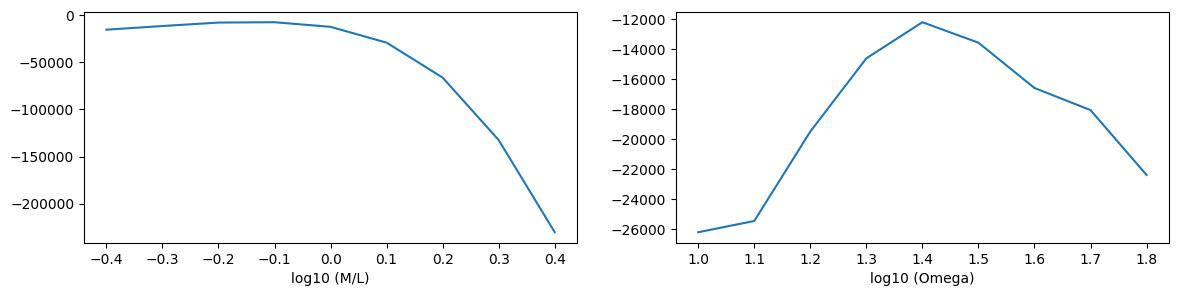

In [ ]:

ground_truth = [
  10.76,
  10.83,
  10.2,
  jnp.log10(7.76).item(),
  jnp.log10(12.0).item(),
  jnp.log10(0.9).item(),
  jnp.log10(4.87).item(),
  25 * jnp.pi / 180,
  65 * jnp.pi / 180,
  45 * jnp.pi / 180,
  0.,
  1.40,
]

fig, ax = plt.subplots(1,2,figsize=(14,3))

logL_ls = []
for i in tqdm(range (0, 9)):

    params_i = [
      10.76,
      10.83,
      10.2,
      jnp.log10(7.76).item(),
      jnp.log10(12.0).item(),
      jnp.log10(0.9).item(),
      jnp.log10(4.87).item(),
      25 * jnp.pi / 180,
      65 * jnp.pi / 180,
      45 * jnp.pi / 180,
      0.,
      1.40,
    ]
    # params_i = prior_center.copy()
    params_i[-2] = params_i[-2] + (i-4)/10
    logL = model_likelihood(params_i, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    logL.block_until_ready()  # Ensure computation finishes before timing
    print('M/L=', 10**params_i[-2], logL)
    logL_ls.append(logL)

ax[0].plot(jnp.arange(-4,5)/10 + ground_truth[-2], logL_ls - np.amin(np.isfinite(logL_ls)))
ax[0].set(xlabel = 'log10 (M/L)')

logL_ls = []
for i in tqdm(range (0, 9)):
    params_i = [
    10.76,
    10.83,
    10.2,
    jnp.log10(7.76).item(),
    jnp.log10(12.0).item(),
    jnp.log10(0.9).item(),
    jnp.log10(4.87).item(),
    25 * jnp.pi / 180,
    65 * jnp.pi / 180,
    45 * jnp.pi / 180,
    0.,
    1.40,]
    params_i[-1] = params_i[-1] + (i-4)/10
    logL = model_likelihood(params_i, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    logL.block_until_ready()  # Ensure computation finishes before timing
    logL_ls.append(logL)
    print('Omega=', 10**params_i[-1], logL)

ax[1].plot(np.arange(-4,5)/10 + ground_truth[-1], logL_ls - np.amin(np.isfinite(logL_ls)))
ax[1].set(xlabel = 'log10 (Omega)')

In [ ]:

path = '/content/drive/MyDrive/SchwarMAX/'

model_likelihood_vmap = jax.vmap(model_likelihood, in_axes=(0, None, None, None))
def log_prob_batch(theta):

    params = jnp.array(theta)
    ll = model_likelihood_vmap(params, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
    ll = np.where(np.isfinite(ll), ll, -np.inf)

    return ll

grid_logM2L = np.linspace(-0.6,0.6,50)
grid_Omega = np.linspace(10,50,50)

param_grid1 = grid_logM2L # log10(L/M)
param_grid2 = np.log10(grid_Omega) # log10(Omega)
Grid1, Grid2 = np.meshgrid(param_grid1, param_grid2)

N_grid = len(Grid1.flatten())

param_grid = np.array([
  10.76 * np.ones(N_grid), # logM_dm_enclosed
  10.83 * np.ones(N_grid), # logM_disc
  10.20 * np.ones(N_grid), # logM_bar
  jnp.log10(7.76).item() * np.ones(N_grid), # logC_halo
  jnp.log10(12.0).item() * np.ones(N_grid),
  jnp.log10(0.90).item() * np.ones(N_grid),
  jnp.log10(4.87).item() * np.ones(N_grid),
  (25 * jnp.pi / 180) * np.ones(N_grid),
  (65 * jnp.pi / 180) * np.ones(N_grid),
  (45 * jnp.pi / 180) * np.ones(N_grid),
  Grid1.flatten(),
  Grid2.flatten(),
]).T

Chunk_size = 12
Chunk_total = (len(param_grid) // Chunk_size) + 1

log_prob_grid = jnp.array([])
log_M2L_grid = jnp.array([])
log_Omega_grid = jnp.array([])
for i in tqdm(range(Chunk_total)):
  params_i = param_grid[i*Chunk_size:(i+1)*Chunk_size]
  logl = log_prob_batch(params_i)
  log_prob_grid = jnp.append(log_prob_grid, logl)
  log_M2L_grid = jnp.append(log_M2L_grid, params_i[:, -2])
  log_Omega_grid = jnp.append(log_Omega_grid, params_i[:, -1])
  if i % 1 == 0:
    pd.DataFrame({
      'log_mass_to_light_ratio': np.array(log_M2L_grid),
      'log_Omega': np.array(log_Omega_grid),
      'log_prob': np.array(log_prob_grid),
    }).to_csv(path + f'results/grid_search_result.csv', index=False)

100%|██████████| 209/209 [1:22:36<00:00, 23.71s/it]


The biased M/L ratio is expected when adopting an analytic density/potential that doesn't match the original galaxy faithfully
The biased will be gone if one adopt the ground truth potential to build Schwarzschild model (see Fig. 4 and B1 in Zhang et al. 2026)


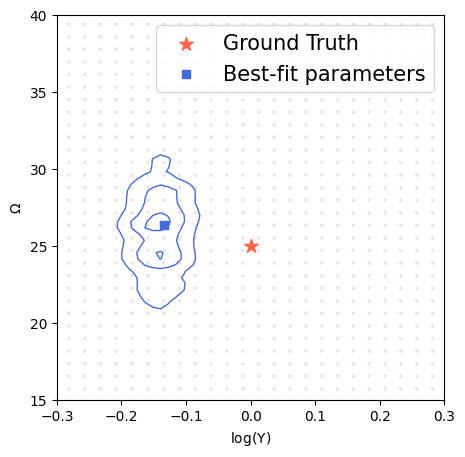

In [12]:

path = '/content/drive/MyDrive/SchwarMAX-final/'
param_names = ['log_mass_to_light_ratio', 'log_Omega']

ground_truth = {
    'mass_to_light_ratio': 1,
    'Omega': 25.0
}


fig, ax = plt.subplots(1,1, figsize=(5, 5))

ax.scatter(np.log10(1/ground_truth['mass_to_light_ratio']), ground_truth['Omega'],
        color='tomato', marker='*', s=100, edgecolor = 'tomato', label='Ground Truth', zorder = 100)

df_param = pd.read_csv(path+f'/results/grid_search_result.csv')
df_param = df_param[np.isfinite(df_param['log_prob'])]
df_param['log_prob'] = df_param['log_prob'] - np.max(df_param['log_prob'])


samples_plot = np.zeros((df_param.shape[0], len(param_names)))
samples_plot[:,0] = df_param['log_mass_to_light_ratio'].to_numpy()
samples_plot[:,1] = 10 ** df_param['log_Omega'].to_numpy()

cb = ax.scatter(samples_plot[:,0], samples_plot[:,1], color = 'lightgrey',
              marker='o', s = 5, edgecolor = 'lightgrey', ls = '--', lw = 0.4, alpha = 0.5)
ax.set_xlabel(r'$\log(\Upsilon)$')
ax.set_ylabel(r'$\Omega$')

idx = np.argmax(df_param['log_prob'])
ax.scatter(samples_plot[idx,0], samples_plot[idx,1],
            color='royalblue', marker='s', s=40, edgecolor = 'royalblue', label=r'Best-fit parameters')

# Draw contour of logL
xi = np.linspace(samples_plot[:,0].min(), samples_plot[:,0].max(), 100)
yi = np.linspace(samples_plot[:,1].min(), samples_plot[:,1].max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

log_prob_smooth = sp.ndimage.gaussian_filter(df_param['log_prob'].to_numpy(), sigma=0.)
Zi = griddata((samples_plot[:,0], samples_plot[:,1]), log_prob_smooth / 50, (Xi, Yi), method='cubic')
ax.contour(Xi, Yi, Zi, levels=[-15, -6, -1.15], colors='royalblue', linewidths=1, alpha=0.99, linestyles='-',
              )
ax.legend(loc = 'upper right', fontsize = 15)
ax.set(xlim=[-0.3, 0.3], ylim=[15, 40])

print("The biased M/L ratio is expected when adopting an analytic density/potential that doesn't match the original galaxy faithfully")
print("The biased will be gone if one adopt the ground truth potential to build Schwarzschild model (see Fig. 4 and B1 in Zhang et al. 2026)")

# Optimisation pipeline

In [8]:
# Jackknife the data to get delta chi2

path = '/content/drive/MyDrive/SchwarMAX/'

MINIMISER_RESULT = os.path.join(path, 'example/minimisation_result.npy')

res = np.load(MINIMISER_RESULT)[:-1]
res[-2] = -res[-2]
res = jnp.array(res)

delta_chi2 = calculate_delta_chi2(res, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'])
print(delta_chi2)

26.466055


In [ ]:
"""
MCMC sampling using BlackJAX. Other sampling method that are friendly to JAX and JAX vmap can also be used, such as numpyro and zeus
vmap runs are a few times faster than running in a chain, so it's better to batch the logL eval and run a batch with JAX vmap
First call will be very slow because of JIT-compilation, but it gets faster after warm up
"""

import blackjax

path = '/content/drive/MyDrive/SchwarMAX/'

N_CHAINS = 32              # number of parallel chains (must fit in GPU vmap)
N_STEPS = 1000             # total MCMC steps per chain
CHECKPOINT_EVERY = 5
BURNIN = 300
ADAPT_EVERY = 50          # re-estimate covariance every N steps
ADAPT_AFTER = 150          # delay adaptation until chains have explored


MINIMISER_RESULT = os.path.join(path, 'example/minimisation_result.npy')
CHECKPOINT_FILE = os.path.join(path, 'example/mcmc_checkpoint.pkl')
OUTPUT_FILE = os.path.join(path, 'example/mcmc_results.pkl')
OUTPUT_CSV = os.path.join(path, 'example/mcmc_posterior.csv')

res = np.load(MINIMISER_RESULT)[:-1]
res[-2] = -res[-2]

# ── Prior bounds (12D) ───────────────────────────────────────────────
NDIM = 12
param_names = [
    'logM_10kpc', 'logM_disk', 'logM_bar', 'logC_halo', 'logRs_disk',
    'logHs_disk', 'logL_bar', 'alpha', 'beta', 'gamma',
    'log_mass_to_light_ratio', 'log_Omega',
]

BOUNDS_LO = jnp.array([
    res[0] - 3, res[1] - 3, res[2] - 3, res[3] - 1,
    res[4] - 1, res[5] - 1, max(0, res[6] - 1),
    0., 0., 0., -2., 0.,
])
BOUNDS_HI = jnp.array([
    res[0] + 3, res[1] + 3, res[2] + 3, res[3] + 1,
    res[4] + 1, res[5] + 1, min(1, res[6] + 1),
    float(jnp.pi), float(jnp.pi / 2), float(jnp.pi), 2., 2.,
])

# ── Log-posterior ────────────────────────────────────────────────────
def logdensity_fn(theta):
    in_bounds = jnp.all((theta >= BOUNDS_LO) & (theta <= BOUNDS_HI))
    log_vol = jnp.sum(jnp.log(BOUNDS_HI - BOUNDS_LO))
    logprior = jnp.where(in_bounds, -log_vol, -jnp.inf)

    ll = model_likelihood(theta, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'], sigma_amplify = jnp.sqrt(delta_chi2))
    ll = jnp.where(jnp.isfinite(ll), ll, -1e30)

    return logprior + ll

print('initial parameters:')
for i in range (len(param_names)):
    print(param_names[i], res[i])

print('begining logL', model_likelihood(res, dict_data, dict_data['total_bins'], dict_data['Rzphi_n_tot'], sigma_amplify = jnp.sqrt(delta_chi2)))
# ── Initial proposal (small for ~30-40% acceptance) ──────────────────
OPTIMAL_SCALE = 2.38 / np.sqrt(NDIM)  # Roberts & Rosenthal 2001

initial_guess_sigma = jnp.array([
    0.05,
    0.05,
    0.05,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.10,
    0.05,
    0.10,
])

rmh_sigma_init = jnp.array([
    0.05,
    0.05,
    0.05,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.02,
    0.07,
    0.02,
    0.02,
])

# ── Helper: build sampler from proposal ──────────────────────────────
def build_sampler(proposal):
    rw = blackjax.additive_step_random_walk(logdensity_fn, proposal)
    return jax.vmap(rw.step), jax.vmap(rw.init)

N_HALF = N_CHAINS // 2  # each vmap batch size

def _split_pytree(tree):
    """Split a pytree of (N_CHAINS, ...) arrays into two halves."""
    return (jax.tree.map(lambda x: x[:N_HALF], tree),
            jax.tree.map(lambda x: x[N_HALF:], tree))

def _merge_pytree(tree0, tree1):
    """Merge two pytree halves back into (N_CHAINS, ...)."""
    return jax.tree.map(lambda a, b: jnp.concatenate([a, b], axis=0), tree0, tree1)

def batched_init(vmap_init, positions):
    """Initialise states in two batches to avoid OOM."""
    states_0 = vmap_init(positions[:N_HALF])
    states_1 = vmap_init(positions[N_HALF:])
    return _merge_pytree(states_0, states_1)

def batched_step(vmap_step, keys, states):
    """Run one MCMC step in two batches to avoid OOM."""
    states_0, states_1 = _split_pytree(states)
    keys_0, keys_1 = keys[:N_HALF], keys[N_HALF:]
    new_states_0, infos_0 = vmap_step(keys_0, states_0)
    new_states_1, infos_1 = vmap_step(keys_1, states_1)
    return _merge_pytree(new_states_0, new_states_1), _merge_pytree(infos_0, infos_1)

# ── Initial positions ────────────────────────────────────────────────
def make_init_positions(rng_key):
    """Start chains near best-fit with small perturbation."""
    p0 = jnp.array(res)

    noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * initial_guess_sigma[None, :]
    # init_spread = 0.05 * jnp.ones(len(BOUNDS_HI))# * (BOUNDS_HI - BOUNDS_LO) / 2.0
    # noise = jax.random.normal(rng_key, shape=(N_CHAINS, NDIM)) * init_spread[None, :]

    positions = p0[None, :] + noise
    positions = jnp.clip(positions, BOUNDS_LO[None, :], BOUNDS_HI[None, :])
    return positions


# ── Checkpointing ───────────────────────────────────────────────────
def save_checkpoint(all_samples, all_logprob, step, rng_key, adapt_count=0,
                    proposal_L=None, scale_factor=1.0):
    ckpt = {
        'all_samples': [np.array(s) for s in all_samples],
        'all_logprob': [np.array(lp) for lp in all_logprob],
        'step': step,
        'rng_key': np.array(rng_key),
        'adapt_count': adapt_count,
        'proposal_L': np.array(proposal_L) if proposal_L is not None else None,
        'scale_factor': scale_factor,
    }
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(ckpt, f)


def load_checkpoint():
    if not os.path.exists(CHECKPOINT_FILE):
        return None
    with open(CHECKPOINT_FILE, 'rb') as f:
        ckpt = pickle.load(f)
    n_steps = len(ckpt['all_samples'])
    n_chains = ckpt['all_samples'][0].shape[0]
    print(f"Found checkpoint: {n_steps} steps, {n_chains} chains, "
          f"adapt_count={ckpt.get('adapt_count', 0)}")
    return ckpt


# ── Main loop ────────────────────────────────────────────────────────
def run_mcmc(resume=True):
    rng_key = jax.random.PRNGKey(42)

    ckpt = load_checkpoint() if resume else None

    if ckpt is not None:
        # ── Resume from checkpoint ────────────────────────────────
        all_positions = ckpt['all_samples']
        all_logprob = ckpt['all_logprob']
        start_step = ckpt['step']
        rng_key = jnp.array(ckpt['rng_key'])
        adapt_count = ckpt.get('adapt_count', 0)
        proposal_L = ckpt.get('proposal_L', None)
        scale_factor = ckpt.get('scale_factor', 1.0)

        # Reconstruct states from last saved positions/logprob
        last_positions = jnp.array(all_positions[-1])
        if proposal_L is not None:
            proposal = blackjax.mcmc.random_walk.normal(
                jnp.array(proposal_L * scale_factor))
        else:
            proposal = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step, vmap_init = build_sampler(proposal)
        states = batched_init(vmap_init, last_positions)

        print(f"Resumed from step {start_step}, {len(all_positions)} samples, "
              f"adapt_count={adapt_count}, scale_factor={scale_factor:.3f}")
    else:
        # ── Fresh start ───────────────────────────────────────────
        rng_key, init_key = jax.random.split(rng_key)
        positions = make_init_positions(init_key)

        print(f"Initialising {N_CHAINS} chains in 2 batches of {N_HALF}...")
        proposal_init = blackjax.mcmc.random_walk.normal(rmh_sigma_init)
        vmap_step, vmap_init = build_sampler(proposal_init)
        states = batched_init(vmap_init, positions)
        print(f"  Init done.")
        all_positions = []
        all_logprob = []
        start_step = 0
        adapt_count = 0
        proposal_L = None
        scale_factor = 1.0

    # Track recent acceptance (last ADAPT_EVERY steps)
    recent_accepts = []

    print(f"\nAdaptive RMH: {N_CHAINS} chains, {N_STEPS} steps, {NDIM}D")
    print(f"  Adapt covariance every {ADAPT_EVERY} steps after step {ADAPT_AFTER}")
    print(f"  Using all samples from step {ADAPT_AFTER} onward for covariance")
    print(f"  Optimal scale: {OPTIMAL_SCALE:.3f}")
    print(f"  Starting from step {start_step + 1}")

    pbar = tqdm(range(start_step + 1, N_STEPS + 1), desc="RMH", unit="step")
    for step in pbar:
        rng_key, step_key = jax.random.split(rng_key)
        keys = jax.random.split(step_key, N_CHAINS)

        states, infos = batched_step(vmap_step, keys, states)

        all_positions.append(np.array(states.position))
        all_logprob.append(np.array(states.logdensity))

        step_accept = float(jnp.mean(infos.acceptance_rate))
        recent_accepts.append(step_accept)
        if len(recent_accepts) > ADAPT_EVERY:
            recent_accepts.pop(0)

        # ── Adapt proposal covariance ────────────────────────────
        if step >= ADAPT_AFTER and step % ADAPT_EVERY == 0:
            # Use samples from ADAPT_AFTER onward (skip burn-in)
            samples_post_burnin = np.stack(all_positions[int(max(ADAPT_AFTER-50, step-200)):], axis=0)
            flat = samples_post_burnin.reshape(-1, NDIM)
            n_used = flat.shape[0]

            if n_used > 2 * NDIM:
                cov = np.cov(flat.T)
                diag = np.diag(np.diag(cov))
                cov_reg = 0.8 * cov + 0.2 * diag
                proposal_cov = OPTIMAL_SCALE**2 * cov_reg
                try:
                    L = np.linalg.cholesky(proposal_cov)
                    proposal_L = L

                    recent_acc = np.mean(recent_accepts)

                    proposal = blackjax.mcmc.random_walk.normal(
                        jnp.array(L * scale_factor))
                    vmap_step, _ = build_sampler(proposal)
                    adapt_count += 1

                    tqdm.write(
                        f"  [Adapt #{adapt_count} at step {step}] "
                        f"recent_acc={recent_acc:.3f}, scale={scale_factor:.3f}, "
                        f"n={n_used}, "
                        f"cov diag={np.sqrt(np.diag(proposal_cov))[:3].round(4)}")
                except np.linalg.LinAlgError:
                    tqdm.write(f"  [Adapt #{adapt_count+1} at step {step}] "
                               f"Cholesky failed, keeping current proposal")
            else:
                tqdm.write(f"  [Adapt at step {step}] "
                           f"Too few samples ({n_used}), skipping")

        if step % 5 == 0:
            recent_acc = np.mean(recent_accepts) if recent_accepts else 0.0
            pbar.set_postfix(
                logP=f"{float(jnp.mean(states.logdensity)):.1f}",
                acc=f"{recent_acc:.3f}",
                adapt=adapt_count,
            )

        if step % CHECKPOINT_EVERY == 0:
            save_checkpoint(all_positions, all_logprob, step, rng_key,
                            adapt_count, proposal_L, scale_factor)

    # ── Results ──────────────────────────────────────────────────────
    chain = np.stack(all_positions, axis=0)  # (N_STEPS, N_CHAINS, NDIM)
    logprob = np.stack(all_logprob, axis=0)
    print(f"\nChain shape: {chain.shape}")

    # Flat samples after burn-in
    if chain.shape[0] > BURNIN:
        flat_samples = chain[BURNIN:].reshape(-1, NDIM)
    else:
        flat_samples = chain.reshape(-1, NDIM)

    print(f"\n── Posterior summary ({flat_samples.shape[0]} samples) ──")
    print(f"{'Parameter':>30s} {'mean':>10s} {'std':>10s} "
          f"{'2.5%':>10s} {'97.5%':>10s} {'truth':>10s}")
    print("-" * 82)
    for i, name in enumerate(param_names):
        s = flat_samples[:, i]
        truth = res[i]
        print(f"{name:>30s} {s.mean():10.4f} {s.std():10.4f} "
              f"{np.percentile(s, 2.5):10.4f} {np.percentile(s, 97.5):10.4f} "
              f"{truth:10.4f}")

    # Save
    results = {
        'chain': chain,
        'logprob': logprob,
        'flat_samples': flat_samples,
        'param_names': param_names,
    }
    with open(OUTPUT_FILE, 'wb') as f:
        pickle.dump(results, f)
    print(f"\nResults saved to {OUTPUT_FILE}")

    pd.DataFrame(flat_samples, columns=param_names).to_csv(OUTPUT_CSV, index=False)
    print(f"CSV saved to {OUTPUT_CSV}")

    return chain, logprob


if __name__ == '__main__':
    run_mcmc(resume = False)


initial parameters:
logM_10kpc 10.674979
logM_disk 10.717889
logM_bar 10.196065
logC_halo 0.9875556
logRs_disk 0.97132087
logHs_disk -0.25643212
logL_bar 0.74568737
alpha 0.46487555
beta 1.1576498
gamma 1.0315903
log_mass_to_light_ratio -0.1659575
log_Omega 1.3822253
begining logL -279.49487
Initialising 32 chains in 2 batches of 16...
  Init done.

Adaptive RMH: 32 chains, 1000 steps, 12D
  Adapt covariance every 50 steps after step 150
  Using all samples from step 150 onward for covariance
  Optimal scale: 0.687
  Starting from step 1


RMH:  15%|█▌        | 150/1000 [2:39:33<15:04:05, 63.82s/step, acc=0.030, adapt=1, logP=-275.8]

  [Adapt #1 at step 150] recent_acc=0.030, scale=1.000, n=1600, cov diag=[0.0678 0.0514 0.0302]


RMH:  20%|██        | 200/1000 [3:32:43<14:10:48, 63.81s/step, acc=0.075, adapt=2, logP=-259.0]

  [Adapt #2 at step 200] recent_acc=0.075, scale=1.000, n=3200, cov diag=[0.0739 0.0587 0.0296]


...

  [Adapt #16 at step 900] recent_acc=0.012, scale=1.000, n=6400, cov diag=[0.0298 0.1087 0.019 ]


RMH:  95%|█████████▌| 950/1000 [16:50:49<53:08, 63.76s/step, acc=0.021, adapt=17, logP=-231.2]

  [Adapt #17 at step 950] recent_acc=0.021, scale=1.000, n=6400, cov diag=[0.0283 0.1071 0.0171]


RMH: 100%|██████████| 1000/1000 [17:44:03<00:00, 63.84s/step, acc=0.017, adapt=18, logP=-230.8]


  [Adapt #18 at step 1000] recent_acc=0.017, scale=1.000, n=6400, cov diag=[0.0272 0.1093 0.0155]

Chain shape: (1000, 32, 12)

── Posterior summary (22400 samples) ──
                     Parameter       mean        std       2.5%      97.5%      truth
----------------------------------------------------------------------------------
                    logM_10kpc    10.8545     0.0530    10.7301    10.9432    10.6750
                     logM_disk    11.0553     0.1870    10.7230    11.5306    10.7179
                      logM_bar    10.2243     0.0300    10.1540    10.2729    10.1961
                     logC_halo     0.8389     0.1911     0.5739     1.3083     0.9876
                    logRs_disk     1.3052     0.1083     1.1087     1.5531     0.9713
                    logHs_disk    -0.1398     0.0412    -0.2206    -0.0606    -0.2564
                      logL_bar     0.6665     0.0321     0.5937     0.7195     0.7457
                         alpha     0.4382     0.0105     0.41